
# Case Study: Chapter 6 - Rural Electrification with Microgrid

Authors: Neeraj Dhanraj Bokde (www.neerajbokde.in) and Carlo Fanara

Affiliation: Renewable & Sustainable Energy Research Center, TII, Abu Dhabi

Corresponding author: neeraj.bokde@tii.ae / neerajdhanraj@gmail.com

Description: This script demonstrates scenario-based modeling of a rural microgrid using PyPSA, as described in Chapter 6 ("Microgrids and Distributed Energy Resources"). The study evaluates the system’s performance under four configurations:

The model uses real-world time series data for demand, solar irradiance, and wind generation, enabling realistic assessment of operational cost, renewable utilization, and CO2 emissions under different DER and demand-side management strategies. Results are visualized using comparative plots for load profiles, dispatch, KPIs, and scenario performance. This script is designed as a template for hands-on learning, benchmarking, or extension to more complex microgrid planning problems.

In [20]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Φόρτωση ωριαίας χρονοσειράς 5 ημερών (from OPSD, pre-filtered)
data = pd.read_csv(
    'microgrid_input_timeseries_2020.csv',
    parse_dates=['utc_timestamp'],
    index_col='utc_timestamp'
)

# Όρισε παράθυρο ημερών
start_date = '2020-01-01'
end_date = '2020-01-05'
filtered_data = data.loc[start_date:end_date]

# Εξαγωγή προφίλ για μοντελοποίηση 
load_profile = filtered_data['load_MW'].values
solar_profile = filtered_data['solar_gen_MW'].values
wind_profile = filtered_data['wind_gen_MW'].values


> ## Σενάριο 0: Δημιουργία βασικού δικτύου (ΟΧΙ ΒΕΛΤΙΣΤΟΠΟΙΗΣΗ)

Αυτό το δίκτυο αποτελεί το πρότυπο. Θα το αντιγράψουμε πριν από την επίλυση κάθε σεναρίου.

In [21]:
# ΒΑΣΙΚΟ ΔΙΚΤΥΟ

base_network = pypsa.Network()
snapshots = pd.date_range(start=start_date, periods=120, freq='h')
base_network.set_snapshots(snapshots)

base_network.add("Bus", "Microgrid Central Bus")

base_network.add("Load", "Microgrid Load",
                 bus="Microgrid Central Bus",
                 p_set=load_profile)

base_network.add("Generator", "Diesel Generator",
                 bus="Microgrid Central Bus",
                 p_nom=3000,
                 marginal_cost=100,
                 carrier="diesel",
                 efficiency=0.35)

base_network.add("Generator", "Grid Supply",
                 bus="Microgrid Central Bus",
                 p_nom=10000,
                 marginal_cost=150,
                 carrier="grid")

> ## Σενάριο 1: Βασική περίπτωση (ντίζελ + δίκτυο)

In [22]:
# Σενάριο 1: Βασική περίπτωση (ντίζελ + δίκτυο)

baseline_network = base_network.copy()
baseline_network.optimize(solver_name='highs')

print("\n=== Scenario 1: Baseline (Diesel + Grid) ===")
print(f"Total system cost: {baseline_network.objective:.2f} $")
print("Diesel energy (MWh):", baseline_network.generators_t.p["Diesel Generator"].sum())
print("Grid energy (MWh):", baseline_network.generators_t.p["Grid Supply"].sum())

Index(['Microgrid Central Bus'], dtype='str', name='name')
Index(['Diesel Generator', 'Grid Supply'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.02s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 240 primals, 600 duals
Objective: 6.98e+07
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.



=== Scenario 1: Baseline (Diesel + Grid) ===
Total system cost: 69793950.00 $
Diesel energy (MWh): 360000.0
Grid energy (MWh): 225293.0


In [23]:
# Scenario 2: Renewable Integration (Solar + Wind)

re_network = base_network.copy()

re_network.add("Generator", "Solar PV",
               bus="Microgrid Central Bus",
               p_nom=1000,
               marginal_cost=10,
               carrier="solar",
               p_max_pu=solar_profile / max(solar_profile),
               capital_cost=600)

re_network.add("Generator", "Wind Turbine",
               bus="Microgrid Central Bus",
               p_nom=1500,
               marginal_cost=12,
               carrier="wind",
               p_max_pu=wind_profile / max(wind_profile),
               capital_cost=800)

re_network.optimize(solver_name='highs')

print("\n=== Scenario 2: Renewable Integration ===")
print(f"Total system cost: {re_network.objective:.2f} $")
print("Solar energy (MWh):", re_network.generators_t.p["Solar PV"].sum())
print("Wind energy (MWh):", re_network.generators_t.p["Wind Turbine"].sum())
print("Diesel energy (MWh):", re_network.generators_t.p["Diesel Generator"].sum())
print("Grid energy (MWh):", re_network.generators_t.p["Grid Supply"].sum())

Index(['Microgrid Central Bus'], dtype='str', name='name')
Index(['Diesel Generator', 'Grid Supply', 'Solar PV', 'Wind Turbine'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.02s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 480 primals, 1080 duals
Objective: 5.35e+07
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.



=== Scenario 2: Renewable Integration ===
Total system cost: 53509164.22 $
Solar energy (MWh): 19941.43484626647
Wind energy (MWh): 99725.45454545454
Diesel energy (MWh): 354617.44349793694
Grid energy (MWh): 111008.66711034207


In [24]:
# Scenario 3: Demand Response (Conservative & Aggressive) Extract dispatch results for DR baseline

initial_load = base_network.loads_t.p_set["Microgrid Load"]

# For DR logic, use the renewable system's dispatch
solar_gen = re_network.generators_t.p["Solar PV"]
wind_gen = re_network.generators_t.p["Wind Turbine"]

combined_gen = solar_gen + wind_gen
threshold = combined_gen.quantile(0.75)


# Demand Response adjustment profiles
dr_adj_cons = combined_gen.apply(lambda x: 1.1 if x > threshold else 0.9)
dr_adj_aggr = combined_gen.apply(lambda x: 1.2 if x > threshold else 0.8)

# Create new load profiles

load_cons = initial_load * dr_adj_cons.values
load_aggr = initial_load * dr_adj_aggr.values

#Conservative DR scenario

conservative_network = base_network.copy()

#Add renewables as before

conservative_network.add("Generator", "Solar PV",
                         bus="Microgrid Central Bus",
                         p_nom=1000,
                         marginal_cost=10,
                         carrier="solar",
                         p_max_pu=solar_profile / max(solar_profile),
                         capital_cost=600)
conservative_network.add("Generator", "Wind Turbine",
                         bus="Microgrid Central Bus",
                         p_nom=1500,
                         marginal_cost=12,
                         carrier="wind",
                         p_max_pu=wind_profile / max(wind_profile),
                         capital_cost=800)

# Update the load profile for DR

conservative_network.loads_t.p_set["Microgrid Load"] = load_cons

conservative_network.optimize(solver_name='highs')




Index(['Microgrid Central Bus'], dtype='str', name='name')
Index(['Diesel Generator', 'Grid Supply', 'Solar PV', 'Wind Turbine'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.02s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 480 primals, 1080 duals
Objective: 4.93e+07
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


('ok', 'optimal')

In [25]:
# Aggressive DR scenario

aggressive_network = base_network.copy()
aggressive_network.add("Generator", "Solar PV",
                       bus="Microgrid Central Bus",
                       p_nom=1000,
                       marginal_cost=10,
                       carrier="solar",
                       p_max_pu=solar_profile / max(solar_profile),
                       capital_cost=600)
aggressive_network.add("Generator", "Wind Turbine",
                       bus="Microgrid Central Bus",
                       p_nom=1500,
                       marginal_cost=12,
                       carrier="wind",
                       p_max_pu=wind_profile / max(wind_profile),
                       capital_cost=800)
aggressive_network.loads_t.p_set["Microgrid Load"] = load_aggr

aggressive_network.optimize(solver_name='highs')

print("\n=== Scenario 3: Demand Response ===")
print("Conservative DR - System cost: {:.2f} $".format(conservative_network.objective))
print("Aggressive DR   - System cost: {:.2f} $".format(aggressive_network.objective))



Index(['Microgrid Central Bus'], dtype='str', name='name')
Index(['Diesel Generator', 'Grid Supply', 'Solar PV', 'Wind Turbine'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 480 primals, 1080 duals
Objective: 4.56e+07
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.



=== Scenario 3: Demand Response ===
Conservative DR - System cost: 49328462.04 $
Aggressive DR   - System cost: 45642773.17 $


## VISUALIZATION

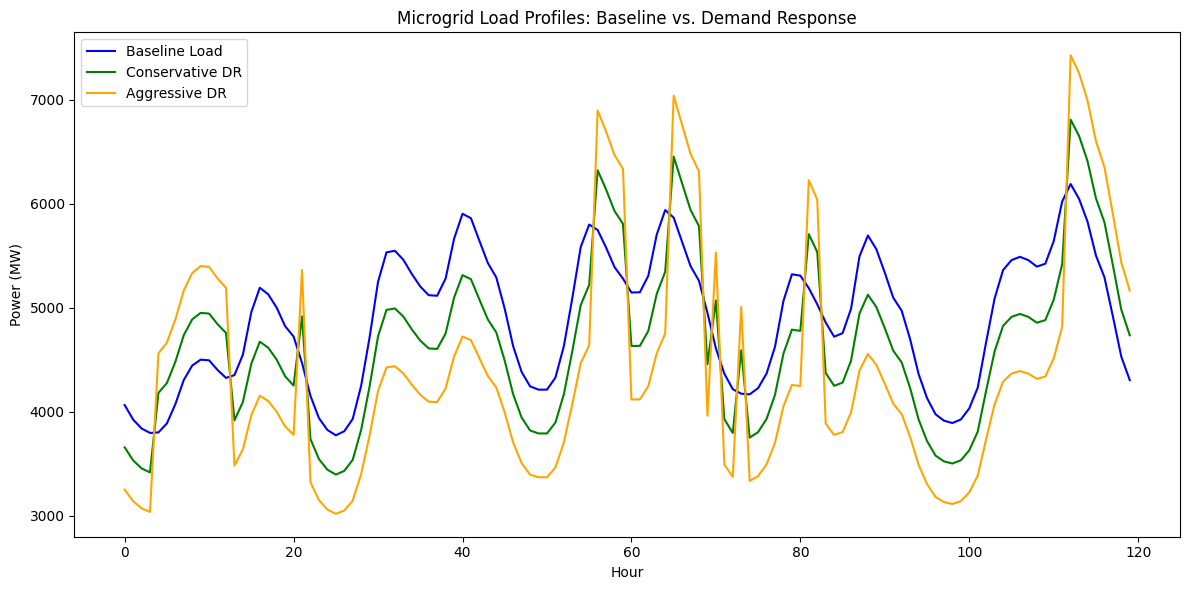

In [ ]:
#Visualization: Load Profiles
plt.figure(figsize=(12, 6))
plt.plot(initial_load.values, label='Baseline Load', color='blue')
plt.plot(load_cons.values, label='Conservative DR', color='green')
plt.plot(load_aggr.values, label='Aggressive DR', color='orange')
plt.title('Microgrid Load Profiles: Baseline vs. Demand Response')
plt.xlabel('Hour')
plt.ylabel('Power (MW)')
plt.legend()
plt.tight_layout()
plt.show()

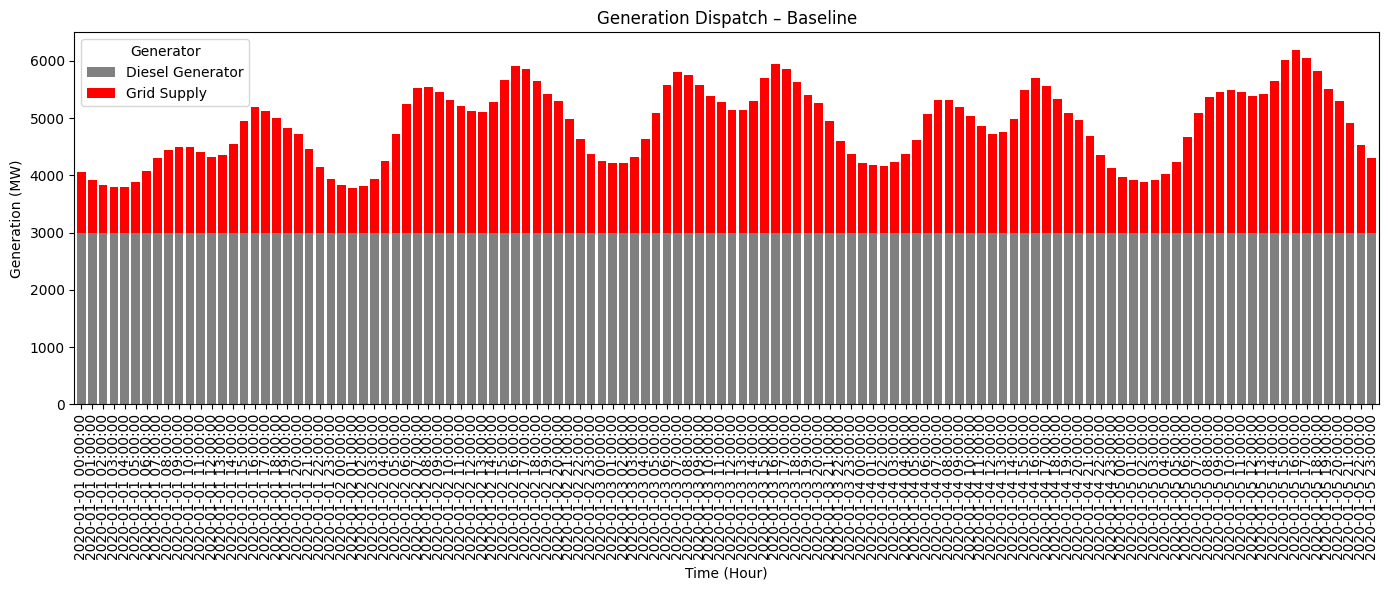

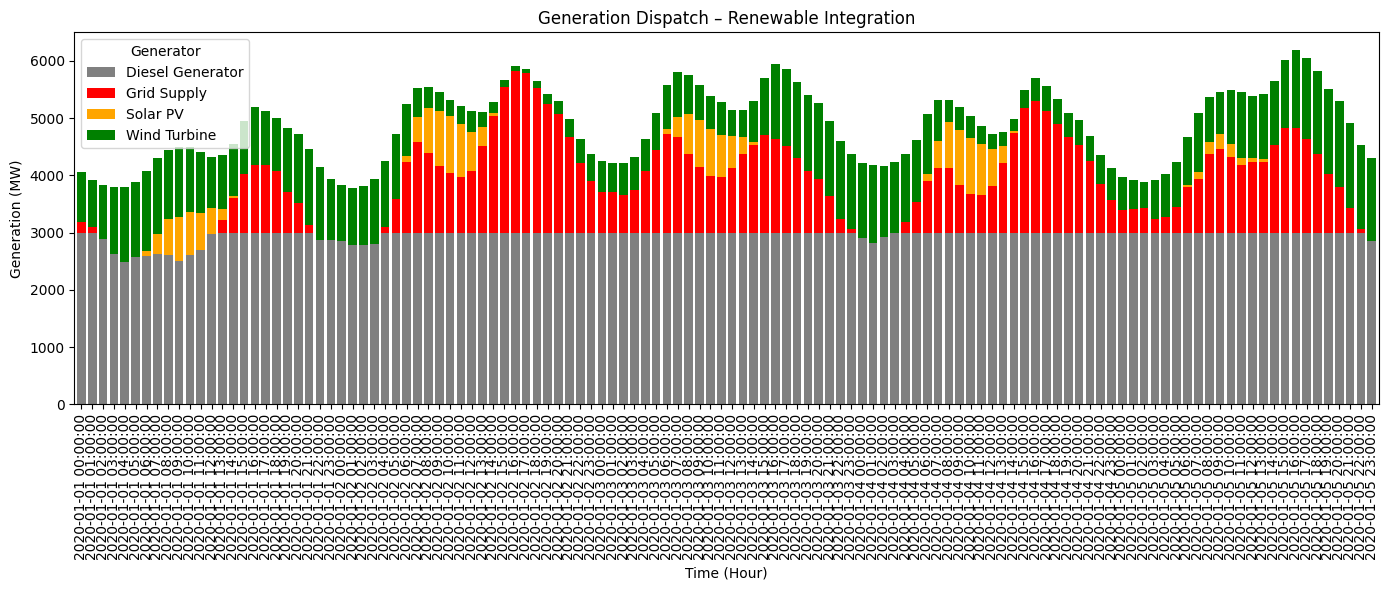

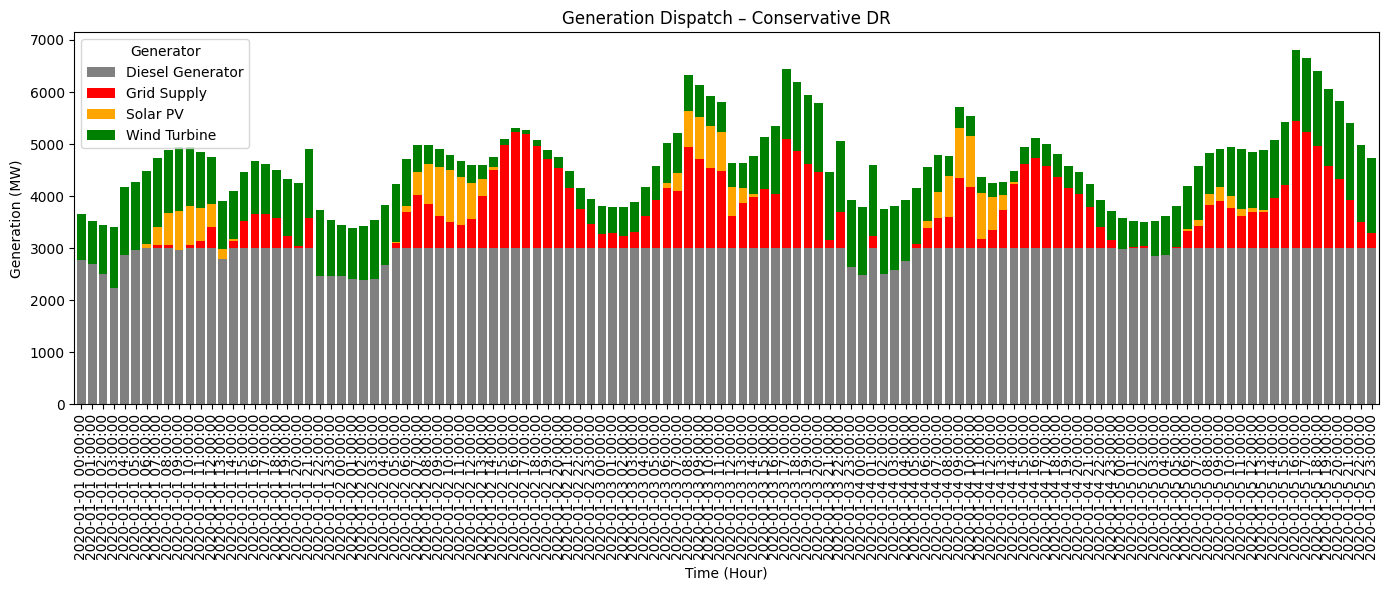

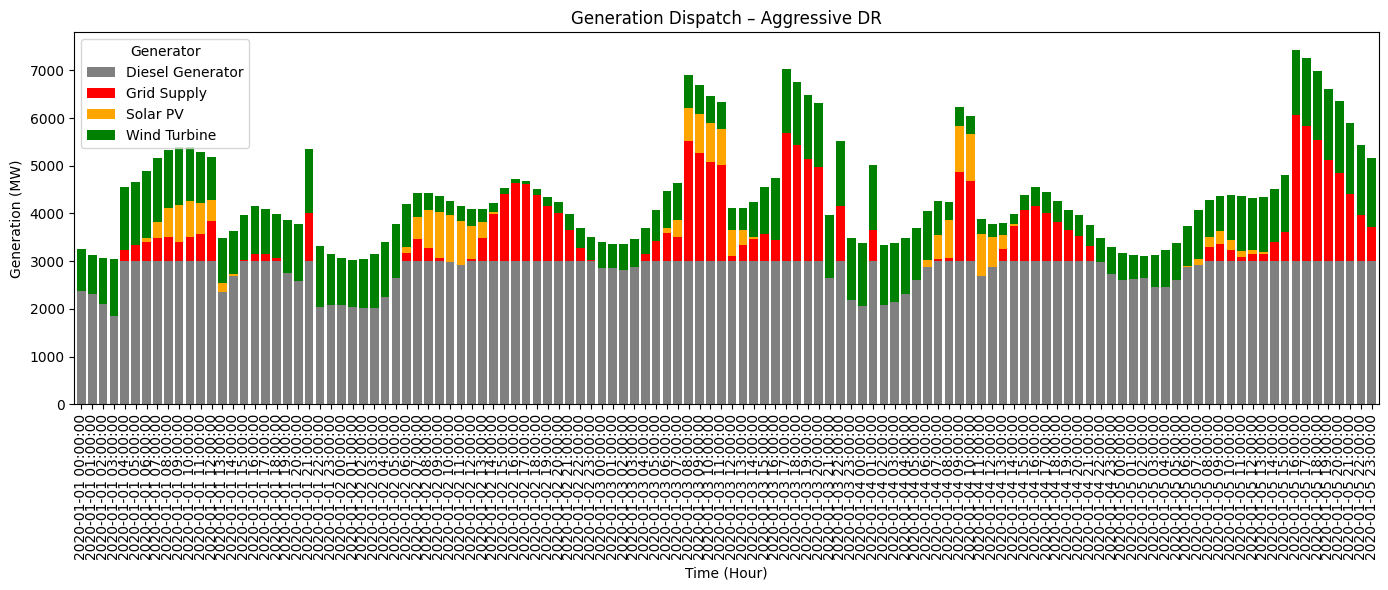

In [27]:
# Visualization: Generation Dispatch (All Scenarios)
def plot_dispatch(network, title):
    gen_dispatch = network.generators_t.p
    colors = {
        'Diesel Generator': 'grey',
        'Grid Supply': 'red',
        'Solar PV': 'orange',
        'Wind Turbine': 'green'
    }
    gen_dispatch.plot(
        kind='bar',
        stacked=True,
        figsize=(14, 6),
        color=[colors.get(gen, 'black') for gen in gen_dispatch.columns],
        width=0.8
    )
    plt.title(title)
    plt.xlabel("Time (Hour)")
    plt.ylabel("Generation (MW)")
    plt.legend(title="Generator")
    plt.tight_layout()
    plt.show()

plot_dispatch(baseline_network, "Generation Dispatch – Baseline")
plot_dispatch(re_network, "Generation Dispatch – Renewable Integration")
plot_dispatch(conservative_network, "Generation Dispatch – Conservative DR")
plot_dispatch(aggressive_network, "Generation Dispatch – Aggressive DR")

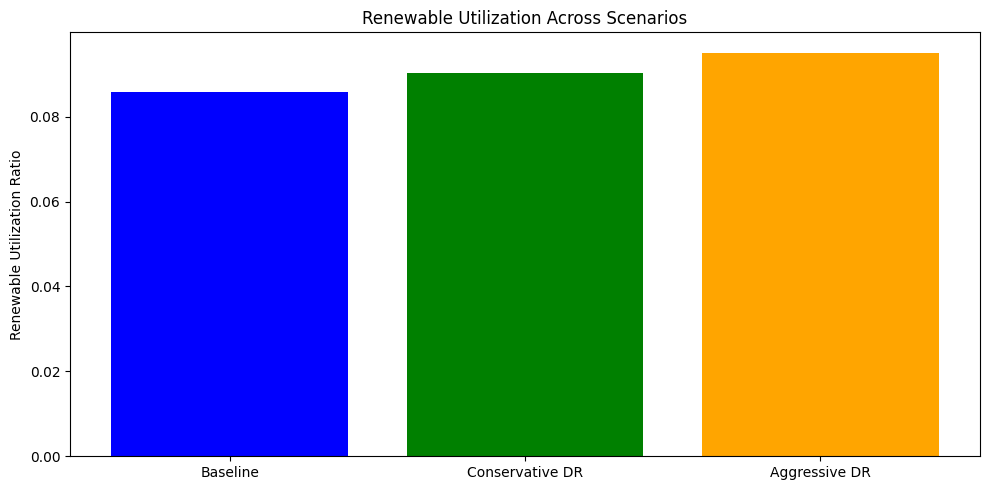

In [28]:
# KPIs: Renewable Utilization, Cost, Emissions - Renewable utilization ratios

total_RE = solar_profile.sum() + wind_profile.sum()
consumption_baseline = initial_load.sum()
consumption_cons = load_cons.sum()
consumption_aggr = load_aggr.sum()

utilization_baseline = total_RE / consumption_baseline
utilization_cons = total_RE / consumption_cons
utilization_aggr = total_RE / consumption_aggr

plt.figure(figsize=(10, 5))
plt.bar(['Baseline', 'Conservative DR', 'Aggressive DR'],
        [utilization_baseline, utilization_cons, utilization_aggr],
        color=['blue', 'green', 'orange'])
plt.ylabel('Renewable Utilization Ratio')
plt.title('Renewable Utilization Across Scenarios')
plt.tight_layout()
plt.show()

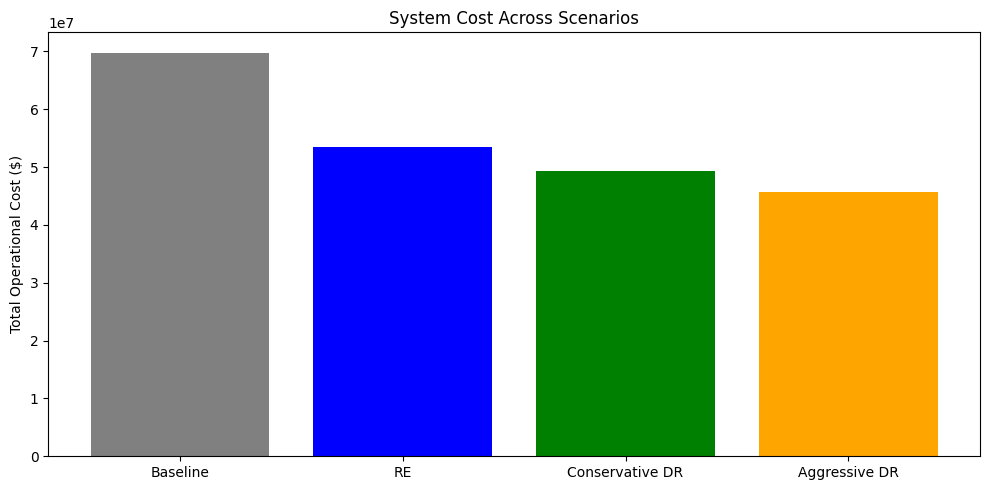

In [29]:
# Economic KPI (total operational cost)

costs = [
    baseline_network.objective,
    re_network.objective,
    conservative_network.objective,
    aggressive_network.objective
]
plt.figure(figsize=(10, 5))
plt.bar(['Baseline', 'RE', 'Conservative DR', 'Aggressive DR'], costs,
        color=['grey', 'blue', 'green', 'orange'])
plt.ylabel('Total Operational Cost ($)')
plt.title('System Cost Across Scenarios')
plt.tight_layout()
plt.show()

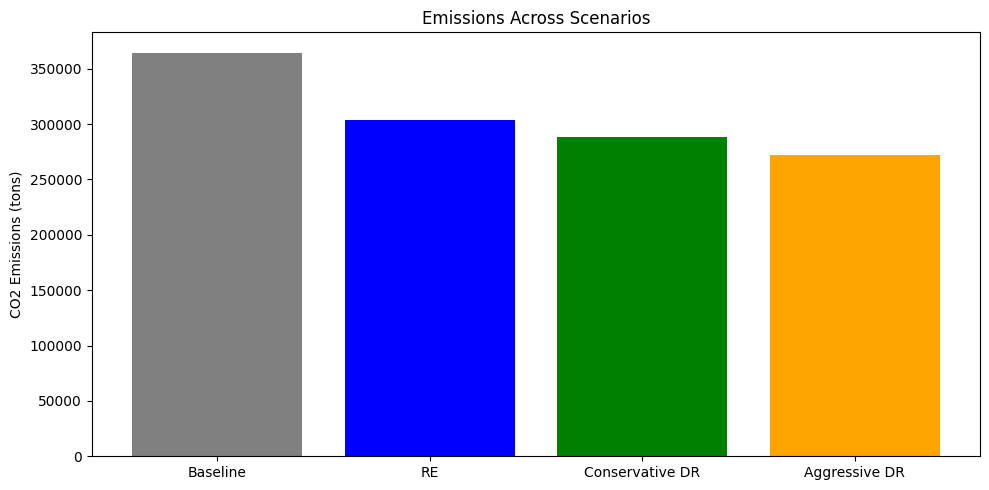


=== KPI Summary ===
Renewable Utilization (Baseline):    0.09
Renewable Utilization (Cons. DR):    0.09
Renewable Utilization (Aggr. DR):    0.10
System Cost (Baseline):              69793950.00 $
System Cost (Cons. DR):              49328462.04 $
System Cost (Aggr. DR):              45642773.17 $
Emissions (Baseline):                364646.50 tons
Emissions (Cons. DR):                288731.28 tons
Emissions (Aggr. DR):                271745.97 tons


In [30]:
# Emissions: 0.7 tons/MWh for diesel, 0.5 for grid

def calculate_emissions(network):
    em = 0
    for gen in network.generators.index:
        if network.generators.carrier[gen] == "diesel":
            em += network.generators_t.p[gen].sum() * 0.7
        elif network.generators.carrier[gen] == "grid":
            em += network.generators_t.p[gen].sum() * 0.5
    return em

emissions = [
    calculate_emissions(baseline_network),
    calculate_emissions(re_network),
    calculate_emissions(conservative_network),
    calculate_emissions(aggressive_network)
]
plt.figure(figsize=(10, 5))
plt.bar(['Baseline', 'RE', 'Conservative DR', 'Aggressive DR'], emissions,
        color=['grey', 'blue', 'green', 'orange'])
plt.ylabel('CO2 Emissions (tons)')
plt.title('Emissions Across Scenarios')
plt.tight_layout()
plt.show()

print("\n=== KPI Summary ===")
print(f"Renewable Utilization (Baseline):    {utilization_baseline:.2f}")
print(f"Renewable Utilization (Cons. DR):    {utilization_cons:.2f}")
print(f"Renewable Utilization (Aggr. DR):    {utilization_aggr:.2f}")
print(f"System Cost (Baseline):              {costs[0]:.2f} $")
print(f"System Cost (Cons. DR):              {costs[2]:.2f} $")
print(f"System Cost (Aggr. DR):              {costs[3]:.2f} $")
print(f"Emissions (Baseline):                {emissions[0]:.2f} tons")
print(f"Emissions (Cons. DR):                {emissions[2]:.2f} tons")
print(f"Emissions (Aggr. DR):                {emissions[3]:.2f} tons")